# From Accuracy to Credibility: Stress-Testing ML Surrogates Using Local and Distortional Buckling Benchmarks

This notebook is **GitHub-ready** and reproduces the full analysis/figures for a study on credibility (not just accuracy) of ML surrogates for:

- **Local-buckling bending moment** (`M_LB`)
- **Distortional-buckling bending moment** (`M_DB`)

Data source: `data.xlsx` (expected at `./data.xlsx` or the path configured below).

## What this notebook produces
- Domain-of-applicability summary (feature ranges)
- In-distribution (ID) performance (train/test split + CV summary)
- Out-of-distribution (OOD) stress tests:
  - Geometry shift (extreme slenderness proxy)
  - Perforation-pattern shift (held-out slot-length group)
  - Material shift (held-out `Fy` group)
- **Conformal prediction intervals** (split conformal) + coverage/sharpness
- Robustness to random seeds (distribution of metrics)
- Feature influence (permutation importance)

> Notes
- The notebook uses **scikit-learn** models by default for maximum portability.
- Optional: if `xgboost` is installed, it will be evaluated too.

---


In [1]:
# ====== Setup ======
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# Optional model (only if installed)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = os.environ.get("DATA_PATH", "data/data.xlsx")  # set env var to override in CI

print("Using DATA_PATH:", DATA_PATH)


Using DATA_PATH: data/data.xlsx


In [2]:
# ====== Load data ======
df = pd.read_excel(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Expected columns
targets = ["M_LB", "M_DB"]
X_cols = [c for c in df.columns if c not in targets]

missing_targets = [t for t in targets if t not in df.columns]
if missing_targets:
    raise ValueError(f"Missing expected target columns: {missing_targets}")

print("Feature columns:", X_cols)
df.head()


Shape: (432, 14)
Columns: ['D', 'Bf', 'Bl', 't', 'Lsl', 'Wsl', 'Ssl', 'Bsl', 'N', 'n', 'Fy', 'r', 'M_LB', 'M_DB']
Feature columns: ['D', 'Bf', 'Bl', 't', 'Lsl', 'Wsl', 'Ssl', 'Bsl', 'N', 'n', 'Fy', 'r']


,D,Bf,Bl,t,Lsl,Wsl,Ssl,Bsl,N,n,Fy,r,M_LB,M_DB
0,150,45,13,1,60,3,100,9.5,1,6,300,2,3.109364,2.730218
1,150,45,13,1,60,5,100,9.5,1,6,300,2,3.104766,2.660462
2,150,45,13,1,75,3,100,9.5,1,6,300,2,3.113055,2.641168
3,150,45,13,1,75,5,100,9.5,1,6,300,2,3.105632,2.552699
4,150,45,13,1,60,3,100,9.5,2,6,300,2,3.086511,2.578204


In [3]:
# ====== Domain-of-applicability table (feature ranges) ======
domain = pd.DataFrame({
    "min": df[X_cols].min(numeric_only=True),
    "max": df[X_cols].max(numeric_only=True),
    "mean": df[X_cols].mean(numeric_only=True),
    "std": df[X_cols].std(numeric_only=True),
}).sort_index()

domain


,min,max,mean,std
Bf,45.0,65.0,55.000000,10.011594
Bl,13.0,13.0,13.000000,0.000000
Bsl,9.5,9.5,9.500000,0.000000
D,150.0,250.0,216.666667,37.311009
Fy,300.0,600.0,466.666667,124.866518
Lsl,60.0,75.0,67.500000,7.508696
N,1.0,2.0,1.500000,0.500580
Ssl,100.0,100.0,100.000000,0.000000
Wsl,3.0,5.0,4.000000,1.001159
n,6.0,12.0,7.666667,2.136849


In [4]:
# Save domain table as CSV for GitHub artifacts
os.makedirs("outputs", exist_ok=True)
domain.to_csv("outputs/domain_of_applicability.csv", index=True)
print("Saved:", "outputs/domain_of_applicability.csv")


Saved: outputs/domain_of_applicability.csv


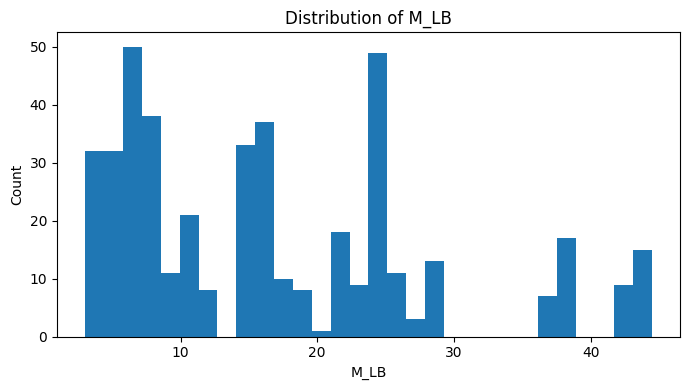

Saved: figures/hist_M_LB.png


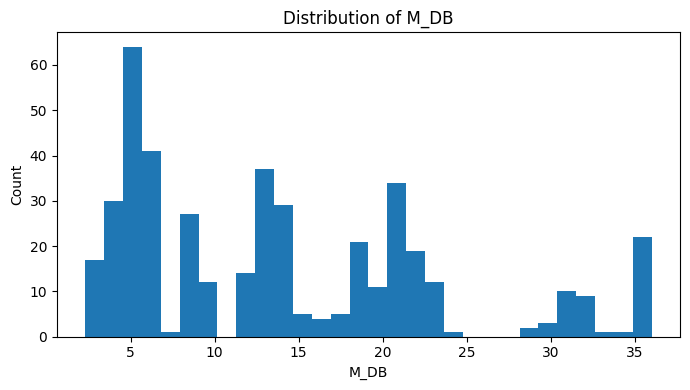

Saved: figures/hist_M_DB.png


In [5]:
# ====== Quick EDA (target distributions) ======
os.makedirs("figures", exist_ok=True)

for t in targets:
    plt.figure(figsize=(7,4))
    plt.hist(df[t].values, bins=30)
    plt.title(f"Distribution of {t}")
    plt.xlabel(t)
    plt.ylabel("Count")
    plt.tight_layout()
    fname = f"figures/hist_{t}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print("Saved:", fname)


In [12]:
# ====== Helper functions ======
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def make_preprocess(feature_cols):
    # numeric pipeline (works for all columns here)
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    pre = ColumnTransformer([("num", num_pipe, feature_cols)], remainder="drop")
    return pre

def build_models(random_state=42):
    models = {
        "RF": RandomForestRegressor(
            n_estimators=600,
            max_features="sqrt" if hasattr(RandomForestRegressor(), "max_features") else 1.0,
            random_state=random_state,
            n_jobs=-1
        ),
        "GBR": GradientBoostingRegressor(random_state=random_state),
        "HGBR": HistGradientBoostingRegressor(random_state=random_state),
        "AdaBoost": AdaBoostRegressor(random_state=random_state),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBRegressor(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=random_state,
            n_jobs=-1
        )
    return models

def fit_eval_id(X, y, feature_cols, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    pre = make_preprocess(feature_cols)
    results = []
    fitted = {}

    for name, model in build_models(random_state).items():
        pipe = Pipeline([("pre", pre), ("model", model)])
        pipe.fit(X_train, y_train)
        yhat = pipe.predict(X_test)
        met = regression_metrics(y_test, yhat)
        met.update({"Model": name, "Split": "ID"})
        results.append(met)
        fitted[name] = pipe

    res = pd.DataFrame(results).sort_values(["MAE"])
    return res, fitted, (X_train, X_test, y_train, y_test)

def choose_group_holdout(series, min_frac=0.12, max_frac=0.35):
    # pick a discrete value group to hold out with enough samples
    vc = series.value_counts(dropna=True)
    n = len(series)
    candidates = []
    for val, cnt in vc.items():
        frac = cnt / n
        if min_frac <= frac <= max_frac:
            candidates.append((abs(frac-0.2), val, cnt, frac))
    if candidates:
        candidates.sort()
        _, val, cnt, frac = candidates[0]
        return val, cnt, frac
    # fallback: hold out the most frequent value if nothing matches
    val = vc.index[0]
    cnt = int(vc.iloc[0])
    frac = cnt / n
    return val, cnt, frac

def split_conformal_intervals(model_pipe, X_train, y_train, X_test, alpha=0.1, calib_size=0.2, random_state=42):
    # Split train into train/calibration
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train, y_train, test_size=calib_size, random_state=random_state
    )
    model_pipe.fit(X_tr, y_tr)
    pred_cal = model_pipe.predict(X_cal)
    resid = np.abs(y_cal - pred_cal)

    n = len(resid)
    # split conformal quantile
    q = np.quantile(resid, np.ceil((n + 1) * (1 - alpha)) / n, method="higher" if hasattr(np, "quantile") else "linear")
    pred_test = model_pipe.predict(X_test)
    lo = pred_test - q
    hi = pred_test + q
    return pred_test, lo, hi, q


In [13]:
# ====== In-distribution (ID) evaluation ======
X = df[X_cols].copy()
id_results = {}

for t in targets:
    y = df[t].copy()
    res, fitted, splits = fit_eval_id(X, y, X_cols, test_size=0.2, random_state=RANDOM_STATE)
    id_results[t] = {"table": res, "models": fitted, "splits": splits}
    print(f"\nID results for {t} (sorted by MAE):")
    display(res)

# Save ID tables
os.makedirs("outputs", exist_ok=True)
for t in targets:
    id_results[t]["table"].to_csv(f"outputs/id_results_{t}.csv", index=False)
    print("Saved:", f"outputs/id_results_{t}.csv")



ID results for M_LB (sorted by MAE):


,MAE,RMSE,R2,Model,Split
4,0.059602,0.088745,0.999947,XGBoost,ID
1,0.177899,0.257343,0.999552,GBR,ID
2,0.342213,0.432976,0.998733,HGBR,ID
0,1.010532,1.278568,0.988949,RF,ID
3,2.092895,2.618620,0.953645,AdaBoost,ID



ID results for M_DB (sorted by MAE):


,MAE,RMSE,R2,Model,Split
4,0.107432,0.266909,0.999276,XGBoost,ID
1,0.242415,0.350241,0.998754,GBR,ID
2,0.361029,0.498644,0.997474,HGBR,ID
0,0.808547,1.021300,0.989404,RF,ID
3,1.538799,1.835023,0.965793,AdaBoost,ID


Saved: outputs/id_results_M_LB.csv
Saved: outputs/id_results_M_DB.csv


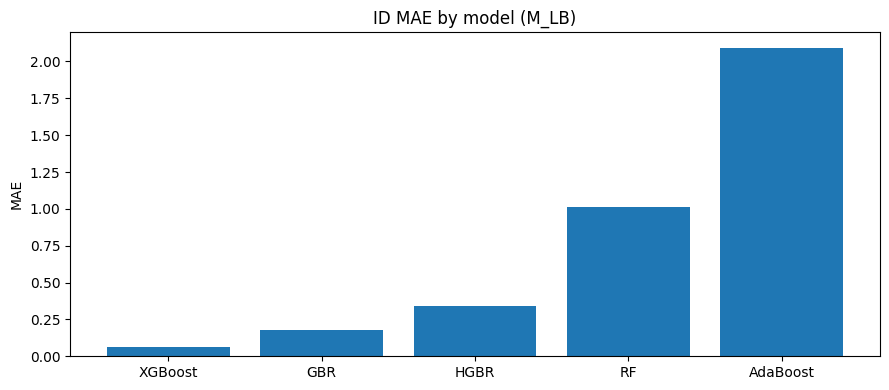

Saved: figures/id_mae_M_LB.png


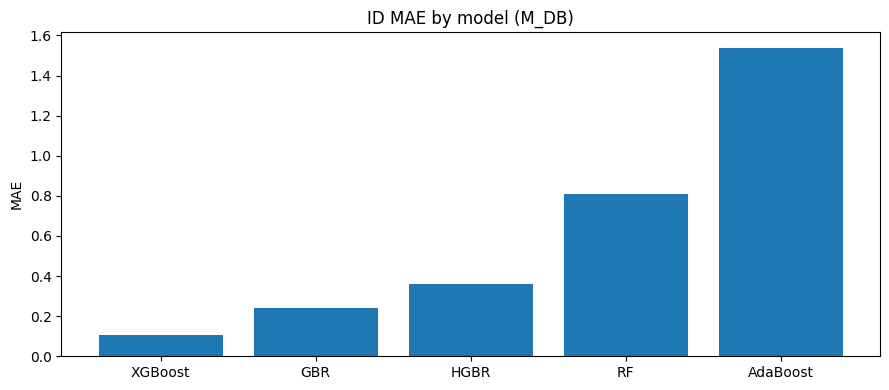

Saved: figures/id_mae_M_DB.png


In [14]:
# ====== Figure: ID performance (MAE, RMSE, R2) ======
for t in targets:
    tab = id_results[t]["table"].copy()
    tab = tab.sort_values("MAE")
    x = np.arange(len(tab))

    plt.figure(figsize=(9,4))
    plt.bar(x, tab["MAE"].values)
    plt.xticks(x, tab["Model"].values, rotation=0)
    plt.title(f"ID MAE by model ({t})")
    plt.ylabel("MAE")
    plt.tight_layout()
    fname = f"figures/id_mae_{t}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print("Saved:", fname)


In [15]:
# ====== OOD stress tests ======
# We define three OOD scenarios using available columns:
# 1) Geometry shift: hold out extreme slenderness proxy based on D/t
# 2) Perforation shift: hold out a discrete Lsl group (slot length)
# 3) Material shift: hold out a discrete Fy group (yield strength)

def ood_split_geometry(df, feature_cols, q=0.15):
    # Use D/t as a slenderness proxy (common in CFS)
    if "D" not in df.columns or "t" not in df.columns:
        raise ValueError("Expected columns D and t for geometry OOD split.")
    slender = (df["D"] / df["t"]).astype(float)
    lo = slender.quantile(q)
    hi = slender.quantile(1-q)
    # Test on extremes (lower q and upper q), train on middle
    is_test = (slender <= lo) | (slender >= hi)
    return is_test, {"proxy": "D/t", "q": q, "lo": float(lo), "hi": float(hi), "test_frac": float(is_test.mean())}

def ood_split_group(df, colname):
    if colname not in df.columns:
        raise ValueError(f"Expected column {colname} for OOD split.")
    val, cnt, frac = choose_group_holdout(df[colname])
    is_test = (df[colname] == val)
    return is_test, {"col": colname, "held_out_value": float(val) if isinstance(val, (int,float,np.number)) else str(val),
                     "count": int(cnt), "test_frac": float(frac)}

ood_scenarios = {
    "OOD-Geometry": lambda _df: ood_split_geometry(_df, X_cols, q=0.15),
    "OOD-Perforation": lambda _df: ood_split_group(_df, "Lsl"),
    "OOD-Material": lambda _df: ood_split_group(_df, "Fy"),
}

ood_results = {t: [] for t in targets}
ood_meta = {}

for scen, splitter in ood_scenarios.items():
    is_test, meta = splitter(df)
    ood_meta[scen] = meta

    X_train = df.loc[~is_test, X_cols].copy()
    X_test  = df.loc[is_test, X_cols].copy()

    for t in targets:
        y_train = df.loc[~is_test, t].copy()
        y_test  = df.loc[is_test, t].copy()

        # Train the best ID model (lowest MAE) for this target
        best_model_name = id_results[t]["table"].iloc[0]["Model"]
        pipe = id_results[t]["models"][best_model_name]

        pipe.fit(X_train, y_train)
        yhat = pipe.predict(X_test)

        met = regression_metrics(y_test, yhat)
        met.update({"Scenario": scen, "Model": best_model_name, "Target": t, "n_test": len(y_test)})
        ood_results[t].append(met)

ood_df = pd.DataFrame([r for t in targets for r in ood_results[t]])
ood_df


,MAE,RMSE,R2,Scenario,Model,Target,n_test
0,14.008434,14.546018,-2.384487,OOD-Geometry,XGBoost,M_LB,144
1,0.163124,0.210775,0.999645,OOD-Perforation,XGBoost,M_LB,216
2,5.868267,7.092604,0.022727,OOD-Material,XGBoost,M_LB,144
3,9.418721,10.048906,-1.341864,OOD-Geometry,XGBoost,M_DB,144
4,0.192009,0.274856,0.999107,OOD-Perforation,XGBoost,M_DB,216
5,4.274720,5.193770,0.311836,OOD-Material,XGBoost,M_DB,144


Saved: outputs/ood_results.csv and outputs/ood_split_metadata.json


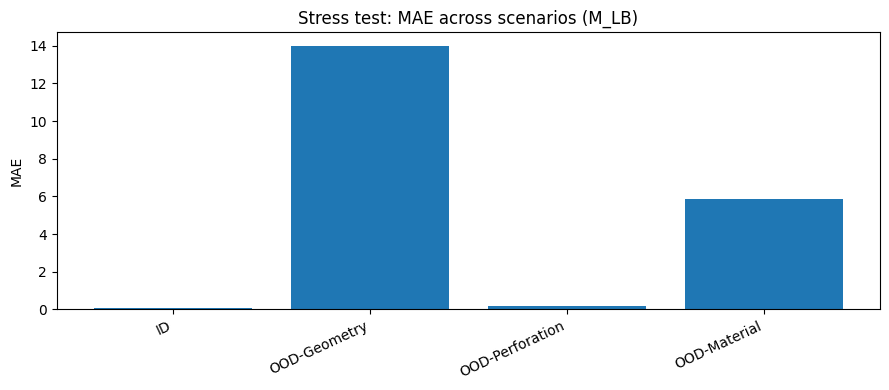

Saved: figures/mae_id_vs_ood_M_LB.png


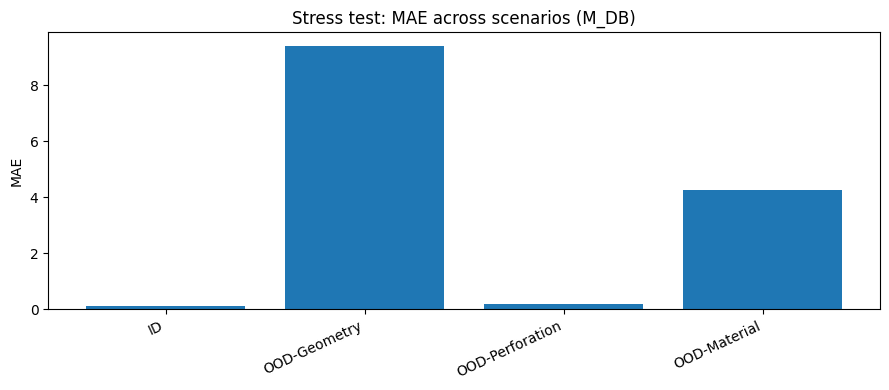

Saved: figures/mae_id_vs_ood_M_DB.png
OOD split metadata used:
{
  "OOD-Geometry": {
    "proxy": "D/t",
    "q": 0.15,
    "lo": 66.66666666666667,
    "hi": 250.0,
    "test_frac": 0.3333333333333333
  },
  "OOD-Perforation": {
    "col": "Lsl",
    "held_out_value": 60.0,
    "count": 216,
    "test_frac": 0.5
  },
  "OOD-Material": {
    "col": "Fy",
    "held_out_value": 300.0,
    "count": 144,
    "test_frac": 0.3333333333333333
  }
}


In [21]:
# Save OOD table
import json
ood_df.to_csv("outputs/ood_results.csv", index=False)
with open("outputs/ood_split_metadata.json", "w") as f:
    json.dump(ood_meta, f, indent=2)
print("Saved: outputs/ood_results.csv and outputs/ood_split_metadata.json")

# Figure: ID vs OOD MAE (for each target)
for t in targets:
    id_best = id_results[t]["table"].iloc[0].copy()
    rows = [{"Scenario":"ID", "MAE": float(id_best["MAE"])}]
    for scen in ood_df.loc[ood_df["Target"]==t, "Scenario"].unique():
        rows.append({"Scenario": scen, "MAE": float(ood_df[(ood_df["Target"]==t) & (ood_df["Scenario"]==scen)]["MAE"].iloc[0])})
    plot_df = pd.DataFrame(rows)

    x = np.arange(len(plot_df))
    plt.figure(figsize=(9,4))
    plt.bar(x, plot_df["MAE"].values)
    plt.xticks(x, plot_df["Scenario"].values, rotation=25, ha="right")
    plt.title(f"Stress test: MAE across scenarios ({t})")
    plt.ylabel("MAE")
    plt.tight_layout()
    fname = f"figures/mae_id_vs_ood_{t}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print("Saved:", fname)

print("OOD split metadata used:")
print(json.dumps(ood_meta, indent=2))


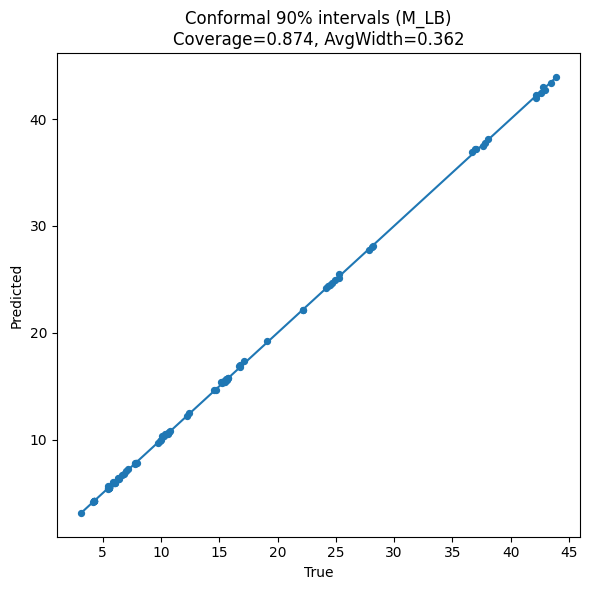

Saved: figures/conformal_intervals_M_LB.png


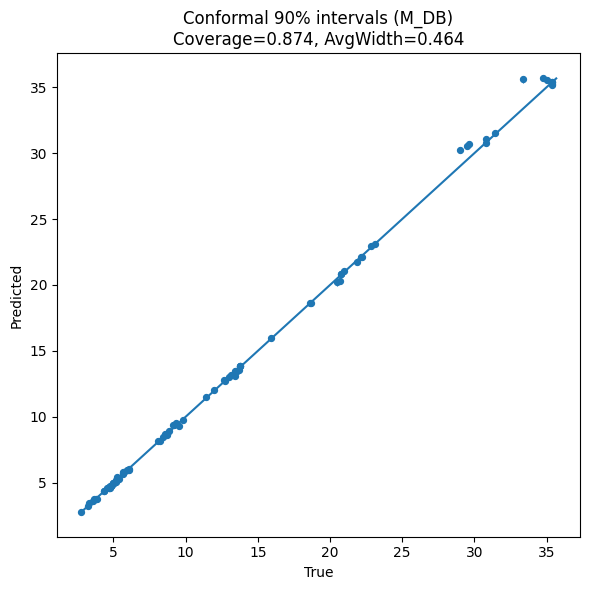

Saved: figures/conformal_intervals_M_DB.png


,Target,Model,alpha,coverage,avg_interval_width,q_residual,n_test
0,M_LB,XGBoost,0.1,0.873563,0.362196,0.181098,87
1,M_DB,XGBoost,0.1,0.873563,0.463650,0.231825,87


In [17]:
# ====== Conformal prediction intervals (split conformal) ======
# We create 90% prediction intervals on the ID test set using split conformal.
alpha = 0.10  # 90% intervals

conformal_summary = []

for t in targets:
    tab = id_results[t]["table"]
    best_model_name = tab.iloc[0]["Model"]
    pipe = id_results[t]["models"][best_model_name]

    X_train, X_test, y_train, y_test = id_results[t]["splits"]
    pred, lo, hi, q = split_conformal_intervals(pipe, X_train, y_train, X_test, alpha=alpha, calib_size=0.25, random_state=RANDOM_STATE)

    coverage = np.mean((y_test.values >= lo) & (y_test.values <= hi))
    avg_width = float(np.mean(hi - lo))

    conformal_summary.append({
        "Target": t,
        "Model": best_model_name,
        "alpha": alpha,
        "coverage": float(coverage),
        "avg_interval_width": avg_width,
        "q_residual": float(q),
        "n_test": int(len(y_test))
    })

    # Plot: predicted vs true with intervals
    plt.figure(figsize=(6,6))
    plt.scatter(y_test.values, pred, s=18)
    # error bars as vertical intervals (sample a subset for readability)
    idx = np.random.choice(len(y_test), size=min(80, len(y_test)), replace=False)
    plt.vlines(y_test.values[idx], lo[idx], hi[idx], linewidth=0.8)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    plt.plot(lims, lims)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Conformal 90% intervals ({t})\nCoverage={coverage:.3f}, AvgWidth={avg_width:.3g}")
    plt.tight_layout()
    fname = f"figures/conformal_intervals_{t}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print("Saved:", fname)

conformal_df = pd.DataFrame(conformal_summary)
conformal_df.to_csv("outputs/conformal_summary.csv", index=False)
conformal_df


In [18]:
# ====== Robustness: variability across random seeds (best model) ======
# We re-train the best-performing model type across multiple seeds and record metrics on the same ID test split.

seeds = list(range(1, 31))  # 30 repeats
robust_rows = []

for t in targets:
    X_train, X_test, y_train, y_test = id_results[t]["splits"]
    best_name = id_results[t]["table"].iloc[0]["Model"]

    for sd in seeds:
        pre = make_preprocess(X_cols)
        models = build_models(random_state=sd)
        model = models[best_name]
        pipe = Pipeline([("pre", pre), ("model", model)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        met = regression_metrics(y_test, pred)
        robust_rows.append({"Target": t, "Model": best_name, "seed": sd, **met})

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv("outputs/robustness_seeds.csv", index=False)
print("Saved: outputs/robustness_seeds.csv")
robust_df.head()


Saved: outputs/robustness_seeds.csv


,Target,Model,seed,MAE,RMSE,R2
0,M_LB,XGBoost,1,0.074438,0.110413,0.999918
1,M_LB,XGBoost,2,0.074429,0.105707,0.999924
2,M_LB,XGBoost,3,0.063079,0.088466,0.999947
3,M_LB,XGBoost,4,0.073240,0.106870,0.999923
4,M_LB,XGBoost,5,0.072577,0.102537,0.999929


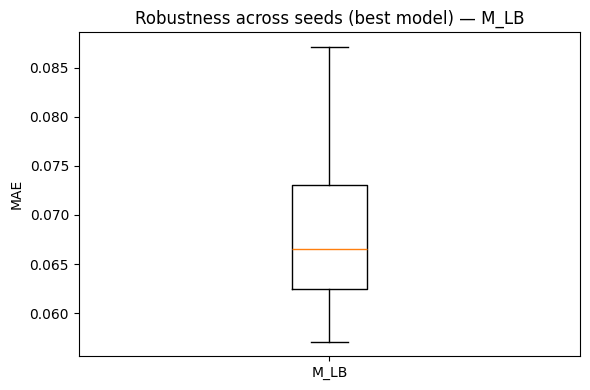

Saved: figures/robustness_mae_box_M_LB.png


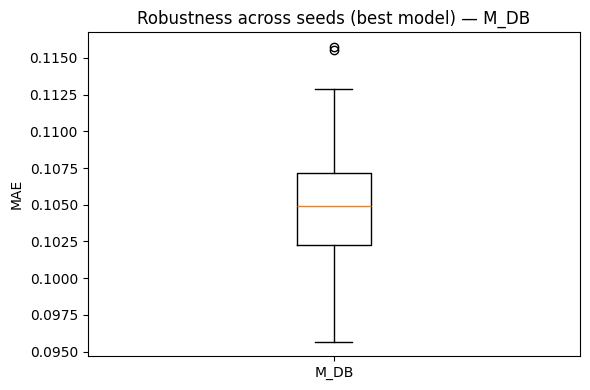

Saved: figures/robustness_mae_box_M_DB.png


In [19]:
# Figure: robustness boxplot (MAE across seeds)
for t in targets:
    vals = robust_df.loc[robust_df["Target"]==t, "MAE"].values
    plt.figure(figsize=(6,4))
    plt.boxplot(vals, vert=True)
    plt.xticks([1], [t])
    plt.ylabel("MAE")
    plt.title(f"Robustness across seeds (best model) — {t}")
    plt.tight_layout()
    fname = f"figures/robustness_mae_box_{t}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print("Saved:", fname)


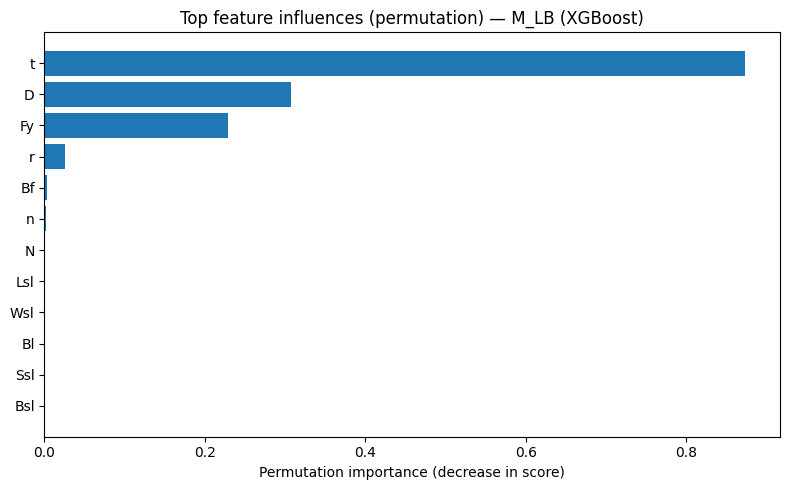

Saved: figures/permutation_importance_M_LB.png and outputs/permutation_importance_M_LB.csv


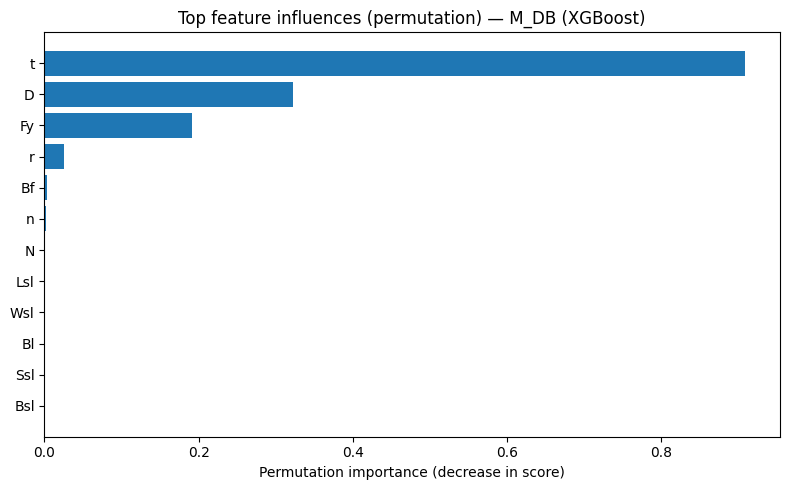

Saved: figures/permutation_importance_M_DB.png and outputs/permutation_importance_M_DB.csv


In [20]:
# ====== Feature influence: permutation importance (best model) ======
# We compute permutation importance on the ID test set for each target.

for t in targets:
    tab = id_results[t]["table"]
    best_name = tab.iloc[0]["Model"]
    pipe = id_results[t]["models"][best_name]

    X_train, X_test, y_train, y_test = id_results[t]["splits"]
    pipe.fit(X_train, y_train)

    r = permutation_importance(pipe, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.DataFrame({"feature": X_cols, "importance": r.importances_mean, "std": r.importances_std})
    imp = imp.sort_values("importance", ascending=False)

    imp.to_csv(f"outputs/permutation_importance_{t}.csv", index=False)

    # Plot top 12
    top = imp.head(12).iloc[::-1]
    plt.figure(figsize=(8,5))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Permutation importance (decrease in score)")
    plt.title(f"Top feature influences (permutation) — {t} ({best_name})")
    plt.tight_layout()
    fname = f"figures/permutation_importance_{t}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print("Saved:", fname, "and", f"outputs/permutation_importance_{t}.csv")


## Reproducibility checklist (for GitHub)

This repo should include:
- `data.xlsx` (or a script to fetch it)
- This notebook
- `requirements.txt` (suggested below)
- The generated `figures/` and `outputs/` folders (or CI to build them)

Suggested `requirements.txt`:
```text
numpy
pandas
matplotlib
scikit-learn
openpyxl
xgboost; platform_system != "Windows"  # optional
```
